=== Summary (seconds) ===
Hand on → Pull | Animal 1: n=54, median=0.389 (IQR 0.340–0.424), mean=0.382
Hand on → Pull | Animal 2: n=56, median=0.309 (IQR 0.174–0.457), mean=0.323
Hand on → Hand off | Animal 1: n=54, median=1.000 (IQR 0.875–1.100), mean=0.978
Hand on → Hand off | Animal 2: n=56, median=1.333 (IQR 1.058–1.516), mean=1.318


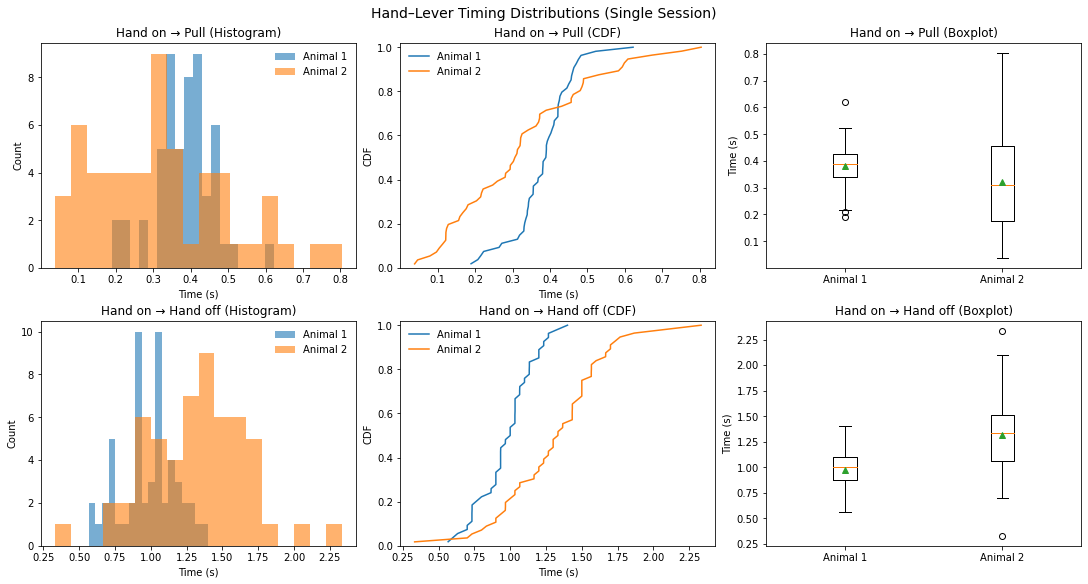

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1) Load data
# -------------------------
csv_path = "20250430_MC_Dodson_Kanga_pull_related_time.csv"
df = pd.read_csv(csv_path)

# Expected columns:
# animal1_on_to_pull, animal2_on_to_pull
# animal1_pull_to_off, animal2_pull_to_off

# -------------------------
# 2) Basic cleaning
# -------------------------
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(how="all")

# -------------------------
# 3) Compute on_to_off
# -------------------------
df["animal1_on_to_off"] = df["animal1_on_to_pull"] + df["animal1_pull_to_off"]
df["animal2_on_to_off"] = df["animal2_on_to_pull"] + df["animal2_pull_to_off"]

# -------------------------
# 4) Summary stats
# -------------------------
def summarize(x):
    x = x[~np.isnan(x)]
    return {
        "n": len(x),
        "median": np.median(x),
        "q25": np.quantile(x, 0.25),
        "q75": np.quantile(x, 0.75),
        "mean": np.mean(x),
    }

print("=== Summary (seconds) ===")
for label, a1, a2 in [
    ("Hand on → Pull",
     df["animal1_on_to_pull"].to_numpy(),
     df["animal2_on_to_pull"].to_numpy()),

    ("Hand on → Hand off",
     df["animal1_on_to_off"].to_numpy(),
     df["animal2_on_to_off"].to_numpy()),
]:
    for name, arr in zip(["Animal 1", "Animal 2"], [a1, a2]):
        s = summarize(arr)
        print(
            f"{label} | {name}: "
            f"n={s['n']}, median={s['median']:.3f} "
            f"(IQR {s['q25']:.3f}–{s['q75']:.3f}), mean={s['mean']:.3f}"
        )

# -------------------------
# 5) Plot helpers
# -------------------------
def plot_hist(ax, x1, x2, title, bins=18):
    ax.hist(x1, bins=bins, alpha=0.6, label="Animal 1")
    ax.hist(x2, bins=bins, alpha=0.6, label="Animal 2")
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)

def plot_cdf(ax, x1, x2, title):
    def cdf(x):
        x = np.sort(x[~np.isnan(x)])
        y = np.arange(1, len(x) + 1) / len(x)
        return x, y

    x1s, y1 = cdf(x1)
    x2s, y2 = cdf(x2)
    ax.plot(x1s, y1, label="Animal 1")
    ax.plot(x2s, y2, label="Animal 2")
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("CDF")
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False)

def plot_box(ax, x1, x2, title):
    ax.boxplot(
        [x1[~np.isnan(x1)], x2[~np.isnan(x2)]],
        labels=["Animal 1", "Animal 2"],
        showmeans=True,
    )
    ax.set_title(title)
    ax.set_ylabel("Time (s)")

# -------------------------
# 6) Extract arrays
# -------------------------
a1_on_to_pull = df["animal1_on_to_pull"].to_numpy()
a2_on_to_pull = df["animal2_on_to_pull"].to_numpy()

a1_on_to_off = df["animal1_on_to_off"].to_numpy()
a2_on_to_off = df["animal2_on_to_off"].to_numpy()

# -------------------------
# 7) Make plots
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

# Row 1: hand on -> pull
plot_hist(axes[0, 0], a1_on_to_pull, a2_on_to_pull, "Hand on → Pull (Histogram)")
plot_cdf(axes[0, 1], a1_on_to_pull, a2_on_to_pull, "Hand on → Pull (CDF)")
plot_box(axes[0, 2], a1_on_to_pull, a2_on_to_pull, "Hand on → Pull (Boxplot)")

# Row 2: hand on -> hand off (computed)
plot_hist(axes[1, 0], a1_on_to_off, a2_on_to_off, "Hand on → Hand off (Histogram)")
plot_cdf(axes[1, 1], a1_on_to_off, a2_on_to_off, "Hand on → Hand off (CDF)")
plot_box(axes[1, 2], a1_on_to_off, a2_on_to_off, "Hand on → Hand off (Boxplot)")

plt.suptitle("Hand–Lever Timing Distributions (Single Session)", fontsize=14)
plt.show()

# -------------------------
# 8) Optional save
# -------------------------
fig.savefig('20250430_MC'+"_hand_on_to_pull_and_hand_off_distributions.pdf", dpi=300, bbox_inches="tight")
